# Project 2 Deep Learning CSCE 636    




# Joseph DeLeonardis UIN: 820000866 March 16th 2026

#Background: The LP Algorithm
The m-height of ta linear code is computer using a Linear programming (LP) algorithm. For each sample, the generator constructs a generator matrix G=[I|P| where I is an identity matrix and P is a randomly generated parity matrix. The algorithm then enumerates over all the m-subsets S of the n code coordinates and for each subset solves a linear program that maximizes the projection of a codeword onto each column direction, subject to the constraint that all other coordinates stay within [-1,1]. The m-height is the largest value found across all these LP solutions. This is computationally expensive. The class was provided a research paper that shows how it can be done with an efficient time complexity but it still posed a challenge.


#Design Choices (Up to the third version)
Several iterations were explored to improve model performance. The first attempt used a single generalized model trained on all 96,524 samples across all 9 (n,k,m) combinations. This approach produced an overall average cost of approximately 0.77. The model struggled because it was asked to simultaneously learn 9 fundamentally different mathematical relationships between the parity matrix P and the m-height using a single set of weights, which proved to be too much for one network to capture effectively.
The second iteration addressed this by training a separate specialized model for each (n,k,m) combination. Feature engineering was also improved, expanding the input from 23 to 36 features by adding sorted column norms, row norms, and additional structural ratios. This brought the overall average cost down to approximately 0.62, confirming that the specialized approach was meaningfully better.
Three combinations continued to show poor results (9,4,5), (9,5,4), and (9,6,3)  with validation losses above 2.1. An attempt was made to improve these by generating additional synthetic training data targeting the underrepresented regions of the height distribution. However this made performance worse, pushing the overall cost up to 1.74. The new samples introduced a distribution shift that the model could not handle, so this approach was abandoned.
The third iteration kept the 9 specialized models but doubled the network architecture  wider layers and an additional hidden layer. This addressed an underfitting problem where the model was not learning the training data well enough regardless of the validation performance. The larger architecture brought the overall average cost down to approximately 0.52. The three problematic combinations still show the highest individual losses due to the mathematical complexity described in the drawbacks section below, but the larger model reduced the overall cost meaningfully compared to all previous versions.

#Last Cell Information
Per the message we got on canvas, I wrote the last cell to run the existing model without the code that would rebuild the model such that a single click can run everything.

#Drive Authorization (if needed)

Attached is the link anyone with the link has access to my CSCE 636 stuff
https://drive.google.com/drive/folders/1LQDy43SQoMe_XayfYz1dpKsNYhpVerxb?usp=sharing

#Final Updates (From project 1)
Before the submission deadline, I wanted to see if I could improve results for the three worst-performing combinations: (9,4,5), (9,5,4), and (9,6,3). These combinations are inherently challenging because m equals the code redundancy n-k, which is the largest value m can take while the height remains finite. At this saturation point the search space is maximally complex and the height values span an enormous range log2(h) from approximately 4 to 22 compared to roughly 1 to 9 for the easier combinations.

Corollary 11 gives a closed form characterization of the height exactly when m = n-k. It states that the height equals the maximum L1 norm of inverse submatrix products of the parity check matrix. Rather than expecting the model to discover this relationship from raw P matrix entries alone, these values were precomputed and added as 10 additional input features for the three hard combinations. This brought the overall average cost from 0.5273 down to 0.2389.

In [4]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')



TRAIN_DATA_PATH   = '/content/drive/MyDrive/CSCE_636/project_1/CSCE-636-Project-1-Train-n_k_m_P'
TRAIN_HEIGHT_PATH = '/content/drive/MyDrive/CSCE_636/project_1/CSCE-636-Project-1-Train-mHeights'
MODEL_SAVE_PATH   = '/content/drive/MyDrive/CSCE_636/project_1/best_model.pth'
NUM_EPOCHS        = 200
BATCH_SIZE        = 256
LEARNING_RATE     = 1e-3

Mounted at /content/drive


In [5]:
#As a sanity check make sure a GPU is selected that can handle this computation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [6]:

with open(TRAIN_DATA_PATH, 'rb') as f:
    train_data = pickle.load(f)
with open(TRAIN_HEIGHT_PATH, 'rb') as f:
    train_heights = pickle.load(f)
print(f'Total samples: {len(train_data):,}')

from itertools import combinations

def compute_c11_features(n, k, P):
    """Compute top Corollary 11 L1 norm values as features."""
    r = n - k
    H = np.hstack([P.T, np.eye(r)])
    col_indices = list(range(n))
    values = []
    for S in combinations(col_indices, r):
        S = list(S)
        H_S = H[:, S]
        if abs(np.linalg.det(H_S)) < 1e-10:
            continue
        H_S_inv = np.linalg.inv(H_S)
        H_S_bar = H[:, [j for j in col_indices if j not in S]]
        for idx in range(len(S)):
            row = H_S_inv[idx, :]
            val = np.sum(np.abs(row @ H_S_bar))
            values.append(val)
    values = sorted(values, reverse=True)
    feat = np.zeros(10)
    feat[:min(len(values), 10)] = values[:10]
    return feat

HARD_COMBOS = {(9,4,5), (9,5,4), (9,6,3)}

def encode_sample(sample):
    n, k, m, P = sample
    col_norms = np.linalg.norm(P, axis=0)
    sort_idx  = np.argsort(-col_norms)
    P_sorted  = P[:, sort_idx]
    p_flat    = P_sorted.flatten()
    p_padded  = np.zeros(20)
    p_padded[:len(p_flat)] = p_flat
    p_padded  = p_padded / 100.0
    col_norms_padded = np.zeros(5)
    col_norms_padded[:len(col_norms)] = np.sort(col_norms)[::-1]
    col_norms_padded = col_norms_padded / 100.0
    row_norms = np.linalg.norm(P, axis=1)
    row_norms_padded = np.zeros(6)
    row_norms_padded[:len(row_norms)] = row_norms
    row_norms_padded = row_norms_padded / 100.0
    scalars = np.array([n/9.0, k/9.0, m/9.0, m/(n-k), k/n])

    if (int(n), int(k), int(m)) in HARD_COMBOS:
        c11_feats = compute_c11_features(n, k, P) / 10000.0
    else:
        c11_feats = np.zeros(10)

    return np.concatenate([scalars, p_padded, col_norms_padded, row_norms_padded, c11_feats]).astype(np.float32)

Total samples: 96,524


In [14]:
class MHeightDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class MHeightDNN(nn.Module):
    def __init__(self, d1=0.2, d2=0.2, d3=0.2, d4=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(46, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(d1),
            nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(d2),
            nn.Linear(1024, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(d3),
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(d4),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def custom_loss(pred, true):
    return torch.mean((true - pred) ** 2)

MODEL_DIR = '/content/drive/MyDrive/CSCE_636/project_2/models'
import os
os.makedirs(MODEL_DIR, exist_ok=True)

# Per-combo dropout tuned from training curves
COMBO_DROPOUT = {
    (9,4,2): (0.20, 0.20, 0.20, 0.10),
    (9,4,3): (0.20, 0.20, 0.20, 0.10),
    (9,4,4): (0.20, 0.20, 0.20, 0.10),
    (9,4,5): (0.50, 0.50, 0.50, 0.40),
    (9,5,2): (0.20, 0.20, 0.20, 0.10),
    (9,5,3): (0.30, 0.30, 0.30, 0.20),
    (9,5,4): (0.50, 0.50, 0.50, 0.40),
    (9,6,2): (0.25, 0.25, 0.25, 0.15),
    (9,6,3): (0.50, 0.50, 0.50, 0.40),
}

PARAM_COMBOS = [
    (9,4,5),(9,5,4),(9,6,3),
    (9,4,2),(9,4,3),(9,4,4),
    (9,5,2),(9,5,3),(9,6,2),
]

def model_path(n, k, m):
    return f'{MODEL_DIR}/model_n{n}_k{k}_m{m}.pth'

combo_results = {}
for (n, k, m) in PARAM_COMBOS:
    print(f'\n{"="*50}')
    print(f'Training (n={n}, k={k}, m={m})')
    idx = [i for i, s in enumerate(train_data) if s[0]==n and s[1]==k and s[2]==m]
    combo_data    = [train_data[i] for i in idx]
    combo_heights = [train_heights[i] for i in idx]
    X = np.array([encode_sample(s) for s in combo_data])
    y = np.array([np.log2(h) for h in combo_heights], dtype=np.float32)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)
    train_loader = DataLoader(MHeightDataset(X_train, y_train), batch_size=256, shuffle=True)
    val_loader   = DataLoader(MHeightDataset(X_val, y_val), batch_size=256, shuffle=False)

    d1, d2, d3, d4 = COMBO_DROPOUT[(n, k, m)]
    model = MHeightDNN(d1=d1, d2=d2, d3=d3, d4=d4).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_val_loss = float('inf')
    for epoch in range(200):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = custom_loss(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_loss += custom_loss(model(X_batch), y_batch).item()
        val_loss /= len(val_loader)
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), model_path(n, k, m))
        if epoch % 20 == 0 or epoch == 199:
            print(f'  Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Best: {best_val_loss:.4f}')
    combo_results[(n,k,m)] = best_val_loss

print('\nAll done:')
for combo, loss in combo_results.items():
    print(f'  {combo}: {loss:.4f}')


Training (n=9, k=4, m=5)
  Epoch   0 | Train: 53.2306 | Val: 43.2160 | Best: 43.2160
  Epoch  20 | Train: 1.2252 | Val: 0.7556 | Best: 0.4585
  Epoch  40 | Train: 1.0060 | Val: 0.9356 | Best: 0.4585
  Epoch  60 | Train: 1.0805 | Val: 0.9946 | Best: 0.4585
  Epoch  80 | Train: 0.9843 | Val: 1.0279 | Best: 0.4585
  Epoch 100 | Train: 1.0022 | Val: 1.2469 | Best: 0.4585
  Epoch 120 | Train: 1.0382 | Val: 0.8613 | Best: 0.4585
  Epoch 140 | Train: 0.9937 | Val: 0.8597 | Best: 0.4585
  Epoch 160 | Train: 1.0272 | Val: 0.8143 | Best: 0.4585
  Epoch 180 | Train: 0.9922 | Val: 0.5799 | Best: 0.4585
  Epoch 199 | Train: 1.0432 | Val: 0.6869 | Best: 0.4585

Training (n=9, k=5, m=4)
  Epoch   0 | Train: 53.0956 | Val: 41.9653 | Best: 41.9653
  Epoch  20 | Train: 1.4348 | Val: 0.6349 | Best: 0.4528
  Epoch  40 | Train: 1.2161 | Val: 1.0558 | Best: 0.4528
  Epoch  60 | Train: 1.1526 | Val: 1.2606 | Best: 0.4528
  Epoch  80 | Train: 1.1882 | Val: 0.8860 | Best: 0.4528
  Epoch 100 | Train: 1.1069 | 

In [21]:
def predict(test_data):
    models = {}
    for (n, k, m) in PARAM_COMBOS:
        mdl = MHeightDNN().to(device)
        mdl.load_state_dict(torch.load(model_path(n, k, m), map_location=device))
        mdl.eval()
        models[(n, k, m)] = mdl
    predictions = []
    for sample in test_data:
        n, k, m, P = sample
        X = torch.tensor(encode_sample(sample), dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            log2_pred = models[(int(n), int(k), int(m))](X).cpu().numpy()[0]
        predictions.append(float(np.maximum(2.0 ** log2_pred, 1.0)))
    return np.array(predictions)

In [22]:
#Test the model performance with a validation set
def validation_prediction(train_data, train_heights):
  #90/10 split
    _, val_idx = train_test_split(np.arange(len(train_data)), test_size=0.1, random_state=42)
    val_samples = [train_data[i] for i in val_idx]
    val_true_heights = [train_heights[i] for i in val_idx]

    val_predictions = predict(val_samples)

    for i in range(5):
        print(f'True: {val_true_heights[i]:.4f} | Predicted: {val_predictions[i]:.4f}')

    print(f'\nOverall average cost: {np.mean((np.log2(val_true_heights) - np.log2(val_predictions))**2):.4f}')


validation_prediction(train_data, train_heights)

True: 3588.0000 | Predicted: 5774.4360
True: 7615.5373 | Predicted: 13100.5137
True: 36.9545 | Predicted: 34.6066
True: 8027.4451 | Predicted: 1139.6492
True: 115.9427 | Predicted: 122.9615

Overall average cost: 0.2544


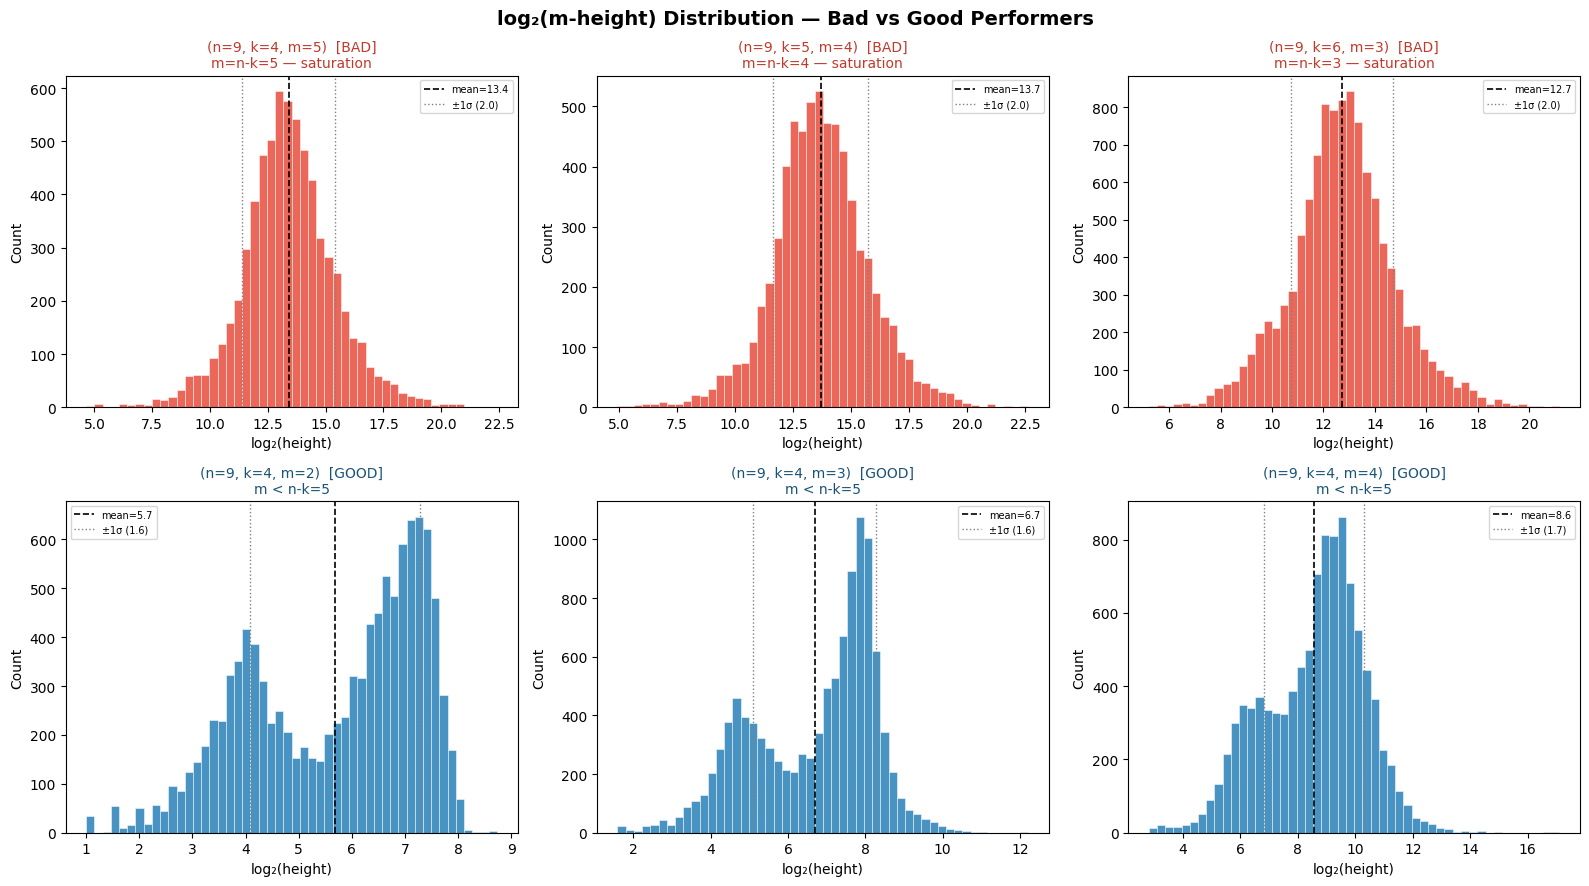


Combo          Type     N        Mean log2h     Std log2h    Min      Max     
────────────────────────────────────────────────────────────────────────
(9,4,5)       BAD      6765     13.394         1.997        4.64     22.41   
(9,5,4)       BAD      6573     13.702         2.036        4.95     22.62   
(9,6,3)       BAD      10913    12.736         1.986        5.21     21.17   
(9,4,2)       GOOD     11157    5.681          1.597        1.00     8.73    
(9,4,3)       GOOD     11003    6.686          1.605        1.58     12.22   
(9,4,4)       GOOD     10253    8.567          1.741        2.81     17.10   
(9,5,2)       GOOD     10803    6.764          1.604        1.58     12.11   
(9,5,3)       GOOD     10159    8.691          1.737        2.58     15.35   
(9,6,2)       GOOD     18898    7.669          1.726        2.32     14.81   


In [10]:
# ─── Histogram Analysis for Hard Combo (bad performers) ───────────────────────
import matplotlib.pyplot as plt
import numpy as np

HARD_COMBOS = [(9, 4, 5), (9, 5, 4), (9, 6, 3)]
EASY_COMBOS = [(9, 4, 2), (9, 4, 3), (9, 4, 4),
               (9, 5, 2), (9, 5, 3),
               (9, 6, 2)]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("log₂(m-height) Distribution — Bad vs Good Performers", fontsize=14, fontweight='bold')

# ── Top row: the 3 hard (bad) combos ──────────────────────────────────────────
for ax, (n, k, m) in zip(axes[0], HARD_COMBOS):
    idx = [i for i, s in enumerate(train_data) if s[0]==n and s[1]==k and s[2]==m]
    heights = np.array([train_heights[i] for i in idx])
    log_h   = np.log2(heights)

    ax.hist(log_h, bins=50, color='#e74c3c', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_title(f"(n={n}, k={k}, m={m})  [BAD]\nm=n-k={n-k} — saturation", fontsize=10, color='#c0392b')
    ax.set_xlabel("log₂(height)")
    ax.set_ylabel("Count")
    ax.axvline(log_h.mean(), color='black', linestyle='--', linewidth=1.2, label=f'mean={log_h.mean():.1f}')
    ax.axvline(log_h.std() + log_h.mean(), color='gray', linestyle=':', linewidth=1, label=f'±1σ ({log_h.std():.1f})')
    ax.axvline(log_h.mean() - log_h.std(), color='gray', linestyle=':', linewidth=1)
    ax.legend(fontsize=7)

# ── Bottom row: 3 representative easy combos for comparison ───────────────────
for ax, (n, k, m) in zip(axes[1], EASY_COMBOS[:3]):
    idx = [i for i, s in enumerate(train_data) if s[0]==n and s[1]==k and s[2]==m]
    heights = np.array([train_heights[i] for i in idx])
    log_h   = np.log2(heights)

    ax.hist(log_h, bins=50, color='#2980b9', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.set_title(f"(n={n}, k={k}, m={m})  [GOOD]\nm < n-k={n-k}", fontsize=10, color='#1a5276')
    ax.set_xlabel("log₂(height)")
    ax.set_ylabel("Count")
    ax.axvline(log_h.mean(), color='black', linestyle='--', linewidth=1.2, label=f'mean={log_h.mean():.1f}')
    ax.axvline(log_h.std() + log_h.mean(), color='gray', linestyle=':', linewidth=1, label=f'±1σ ({log_h.std():.1f})')
    ax.axvline(log_h.mean() - log_h.std(), color='gray', linestyle=':', linewidth=1)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('hard_combo_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary stats table ────────────────────────────────────────────────────────
print(f"\n{'Combo':<14} {'Type':<8} {'N':<8} {'Mean log2h':<14} {'Std log2h':<12} {'Min':<8} {'Max':<8}")
print("─" * 72)
for label, combos in [("BAD", HARD_COMBOS), ("GOOD", EASY_COMBOS)]:
    for (n, k, m) in combos:
        idx = [i for i, s in enumerate(train_data) if s[0]==n and s[1]==k and s[2]==m]
        heights = np.array([train_heights[i] for i in idx])
        log_h   = np.log2(heights)
        print(f"({n},{k},{m})       {label:<8} {len(idx):<8} {log_h.mean():<14.3f} {log_h.std():<12.3f} {log_h.min():<8.2f} {log_h.max():<8.2f}")

In [11]:
for (n, k, m) in [(9,4,5), (9,5,4), (9,6,3)]:
    idx = [i for i, s in enumerate(train_data) if s[0]==n and s[1]==k and s[2]==m]
    combo_data = [train_data[i] for i in idx[:100]]
    p_values = np.concatenate([np.abs(s[3]).flatten() for s in combo_data])
    print(f'({n},{k},{m}): P abs mean={p_values.mean():.3f}  std={p_values.std():.3f}  max={p_values.max():.3f}')

(9,4,5): P abs mean=39.297  std=28.813  max=100.000
(9,5,4): P abs mean=37.648  std=27.139  max=100.000
(9,6,3): P abs mean=34.112  std=25.892  max=100.000


#Code Structure Explained:
The cells above handle data loading, feature engineering, and model training. The final cell below is self-contained and evaluates the pre-trained models without any retraining. All 9 trained model weights are included in the submission. A shared Google Drive link has been provided — if you authenticate and gain access, simply run the last cell as-is with no modifications needed.

In [12]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from itertools import combinations
from google.colab import drive
drive.mount('/content/drive')


# NOTE: Update MODEL_DIR, TRAIN_DATA_PATH, and TRAIN_HEIGHT_PATH to your local paths,
# or authenticate with the provided Google Drive link to run as-is.
#When I zipped the file containing the models for this project i noticed in the stress test the folder name gets nested
# To run the models do the following:
#- Unzip the file and change MODEL_DIR to name of unzipped folder / models
MODEL_DIR = '/content/drive/MyDrive/CSCE_636/project_1/models'
TRAIN_DATA_PATH = '/content/drive/MyDrive/CSCE_636/project_1/CSCE-636-Project-1-Train-n_k_m_P'
TRAIN_HEIGHT_PATH = '/content/drive/MyDrive/CSCE_636/project_1/CSCE-636-Project-1-Train-mHeights'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PARAM_COMBOS = [
    (9,4,2),(9,4,3),(9,4,4),(9,4,5),
    (9,5,2),(9,5,3),(9,5,4),
    (9,6,2),(9,6,3),
]

HARD_COMBOS = {(9,4,5), (9,5,4), (9,6,3)}

def compute_c11_features(n, k, P):
    r = n - k
    H = np.hstack([P.T, np.eye(r)])
    col_indices = list(range(n))
    values = []
    for S in combinations(col_indices, r):
        S = list(S)
        H_S = H[:, S]
        if abs(np.linalg.det(H_S)) < 1e-10:
            continue
        H_S_inv = np.linalg.inv(H_S)
        H_S_bar = H[:, [j for j in col_indices if j not in S]]
        for idx in range(len(S)):
            row = H_S_inv[idx, :]
            val = np.sum(np.abs(row @ H_S_bar))
            values.append(val)
    values = sorted(values, reverse=True)
    feat = np.zeros(10)
    feat[:min(len(values), 10)] = values[:10]
    return feat

def encode_sample(sample):
    n, k, m, P = sample
    col_norms = np.linalg.norm(P, axis=0)
    sort_idx  = np.argsort(-col_norms)
    P_sorted  = P[:, sort_idx]
    p_flat    = P_sorted.flatten()
    p_padded  = np.zeros(20)
    p_padded[:len(p_flat)] = p_flat
    p_padded  = p_padded / 100.0
    col_norms_padded = np.zeros(5)
    col_norms_padded[:len(col_norms)] = np.sort(col_norms)[::-1]
    col_norms_padded = col_norms_padded / 100.0
    row_norms = np.linalg.norm(P, axis=1)
    row_norms_padded = np.zeros(6)
    row_norms_padded[:len(row_norms)] = row_norms
    row_norms_padded = row_norms_padded / 100.0
    scalars = np.array([n/9.0, k/9.0, m/9.0, m/(n-k), k/n])
    if (int(n), int(k), int(m)) in HARD_COMBOS:
        c11_feats = compute_c11_features(n, k, P) / 10000.0
    else:
        c11_feats = np.zeros(10)
    return np.concatenate([scalars, p_padded, col_norms_padded, row_norms_padded, c11_feats]).astype(np.float32)

class MHeightDNN(nn.Module):
    def __init__(self, input_size=46):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(46, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(1024, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def predict(test_data):
    models = {}
    for (n, k, m) in PARAM_COMBOS:
        mdl = MHeightDNN(input_size=46).to(device)
        mdl.load_state_dict(torch.load(
            f'{MODEL_DIR}/model_n{n}_k{k}_m{m}.pth', map_location=device))
        mdl.eval()
        models[(n, k, m)] = mdl
    predictions = []
    for sample in test_data:
        n, k, m, P = sample
        X = torch.tensor(encode_sample(sample), dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            log2_pred = models[(int(n), int(k), int(m))](X).cpu().numpy()[0]
        predictions.append(float(np.maximum(2.0 ** log2_pred, 1.0)))
    return np.array(predictions)

with open(TRAIN_DATA_PATH, 'rb') as f:
    train_data = pickle.load(f)
with open(TRAIN_HEIGHT_PATH, 'rb') as f:
    train_heights = pickle.load(f)

_, val_idx = train_test_split(np.arange(len(train_data)), test_size=0.1, random_state=42)
val_samples = [train_data[i] for i in val_idx]
val_true_heights = [train_heights[i] for i in val_idx]

val_predictions = predict(val_samples)

for i in range(5):
    print(f'True: {val_true_heights[i]:.4f} | Predicted: {val_predictions[i]:.4f}')

print(f'\nOverall average cost: {np.mean((np.log2(val_true_heights) - np.log2(val_predictions))**2):.4f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True: 3588.0000 | Predicted: 7130.5049
True: 7615.5373 | Predicted: 11622.5010
True: 36.9545 | Predicted: 34.4522
True: 8027.4451 | Predicted: 1145.5306
True: 115.9427 | Predicted: 108.8743

Overall average cost: 0.3383


In [13]:


# Load the test set
TEST_DATA_PATH = '/content/drive/MyDrive/CSCE_636/project_1/CSCE-636-Project-1-Test-n_k_m_P'

with open(TEST_DATA_PATH, 'rb') as f:
    test_data = pickle.load(f)

print(f'Test samples: {len(test_data)}')

# Run predictions (uses the models already loaded above)
test_predictions = predict(test_data)

# Save the output
OUTPUT_PATH = '/content/drive/MyDrive/CSCE_636/project_1/CSCE-636-Project-1-Test-mHeights'
with open(OUTPUT_PATH, 'wb') as f:
    pickle.dump(list(test_predictions), f)

print(f'Done! Saved {len(test_predictions)} predictions.')

Test samples: 115816


/tmp/ipykernel_1969/1767572168.py:101: RuntimeWarning: overflow encountered in scalar power
  predictions.append(float(np.maximum(2.0 ** log2_pred, 1.0)))


Done! Saved 115816 predictions.


#References
[1] R. M. Roth, Z. Zhu, C. Yuan, P. H. Siegel, and A. Jiang, "On the height profile of analog error-correcting codes," arXiv:2602.20366v1 [cs.IT], Feb. 2026.

[2] A. Jiang, "Analog error-correcting codes: Designs and analysis," IEEE Transactions on Information Theory, vol. 70, no. 11, pp. 7740-7756, Nov. 2024.
